# 서울 지하철 1~8호선 혼잡도 예측 - 단일 통합 LSTM v2

## 설계 원칙
- **단일 통합 모델**: 285개 역 × 2(승차/하차) — 개별 모델 없음
- **역 임베딩(Station Embedding)**: 역 고유 패턴을 16차원 밀집 벡터로 학습
- **호선 임베딩(Line Embedding)**: 호선별 특성 4차원 표현
- **역+호선 복합 키**: 동명이역 정확 구분

## v2 주요 개선사항
- **[스케일링]** 호선별 개별 MinMaxScaler 적용 → 1·2호선 초고수요 역이 저수요 역 패턴을 누르는 문제 해결
- **[가중치]** 호선별 보정 가중치 추가 (1호선 2.5배, 2호선 2.0배)
- **[하차 모델]** 승차 예측값을 하차 모델 추가 입력으로 연결 (cascaded prediction)
- **[하차 모델]** LSTM 용량 확대: 64→128, 2레이어→3레이어
- **[학습]** validation_split 대신 명시적 val 분리 (train 64% / val 16% / test 20%)
- **[학습]** 하차 모델 patience 10→15 (수렴 느린 특성 반영)


## 1. 라이브러리 임포트

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import joblib, json, os

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout,
                                     Embedding, Flatten, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install workalendar -q
from workalendar.asia import SouthKorea
_cal = SouthKorea()

## 2. 데이터 로드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/project_subway/final_dataset_line1_8_230101-241231.csv'
SAVE_DIR  = '/content/drive/MyDrive/Colab Notebooks/project_subway/line1_8/'
os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
print(f"총 행: {len(df):,}")
print(f"컬럼: {df.columns.tolist()}")
print(f"호선별 역 수:")
print(df.groupby('호선')['역명'].nunique())
print(f"\n전체 고유 역명 수: {df['역명'].nunique()}")
df.head()

총 행: 3,986,800
컬럼: ['날짜', '역명', '호선', '승차인원', '시간', '하차인원', '요일', '월', '공휴일여부', '기온', '강수량', '적설']
호선별 역 수:
호선
1호선    10
2호선    50
3호선    34
4호선    26
5호선    56
6호선    39
7호선    51
8호선    19
Name: 역명, dtype: int64

전체 고유 역명 수: 250


,날짜,역명,호선,승차인원,시간,하차인원,요일,월,공휴일여부,기온,강수량,적설
0,2023-01-01,서울역,1호선,215,5,154,6,1,1,0.8,0.0,0.0
1,2023-01-01,시청,1호선,48,5,64,6,1,1,0.8,0.0,0.0
2,2023-01-01,종각,1호선,407,5,69,6,1,1,0.8,0.0,0.0
3,2023-01-01,종로3가,1호선,220,5,39,6,1,1,0.8,0.0,0.0
4,2023-01-01,종로5가,1호선,46,5,26,6,1,1,0.8,0.0,0.0


## 3. 전처리

### v2 변경점
- **호선별 개별 스케일러**: 1·2호선의 초고수요가 전체 MinMaxScaler를 왜곡하는 문제 해결
- `df_train_scaled`: 호선별 스케일 적용된 학습용 DataFrame
- `scaler`: 전체 피처 역정규화 참조용 (predict_future에서 사용)


In [ ]:
# 정렬
df = df.sort_values(['역명', '호선', '날짜', '시간']).reset_index(drop=True)

# ── 복합 키: 역명 + 호선 (동명이역 완벽 구분) ──────────────────────────────
df['역_키'] = df['역명'] + '_' + df['호선']

dup_names = df.groupby('역명')['호선'].nunique()
print(f"복수 호선 공유 역명 수: {(dup_names > 1).sum()}")
print(dup_names[dup_names > 1].to_dict())

# ── 역 인코딩 (Embedding 입력용 - 역_키 기준) ─────────────────────────────
le_station = LabelEncoder()
df['역명_enc'] = le_station.fit_transform(df['역_키'])
n_stations = df['역명_enc'].nunique()
print(f"\n총 (역+호선) 조합 수 (n_stations): {n_stations}")

# ── 호선 인코딩 (Embedding 입력용) ────────────────────────────────────────
le_line = LabelEncoder()
df['호선_enc'] = le_line.fit_transform(df['호선'])
n_lines = df['호선_enc'].nunique()
print(f"호선 수 (n_lines): {n_lines}  → {dict(zip(le_line.classes_, le_line.transform(le_line.classes_)))}")

# ── 요일×시간 interaction 피처 ────────────────────────────────────────────
df['요일_시간'] = df['요일'] * 24 + df['시간']

# ── 역별 평균 승하차 규모 피처 (원본 기준, 로그 변환 전) ──────────────────
df['역별_평균_승차'] = df.groupby('역_키')['승차인원'].transform('mean')
df['역별_평균_하차'] = df.groupby('역_키')['하차인원'].transform('mean')

# ── 로그 변환 ──────────────────────────────────────────────────────────────
for col in ['승차인원', '하차인원', '역별_평균_승차', '역별_평균_하차']:
    df[col] = np.log1p(df[col])

print("\n로그 변환 완료")
print(f"승차인원 max: {df['승차인원'].max():.4f}  (log1p({int(np.expm1(df['승차인원'].max()))}명))")

# ── 스케일링 피처 목록 ────────────────────────────────────────────────────
numeric_features = [
    '승차인원',        # index 0  (target)
    '하차인원',        # index 1  (target)
    '시간',
    '요일',
    '월',
    '공휴일여부',
    '기온',
    '강수량',
    '적설',
    '요일_시간',
    '역별_평균_승차',
    '역별_평균_하차',
]

# ── [개선] 호선별 개별 스케일러 사용 ─────────────────────────────────────
# 1호선(광역 포함)·2호선(강남·홍대 초고수요)은 스케일이 달라
# 전체 MinMaxScaler로 누르면 저수요 역 패턴이 손실됨.
# → 호선별로 별도 MinMaxScaler 적용 후 df에 덮어씌움.
# 단, scaler (전체 피처 역정규화용) 는 predict_future 등에서 필요하므로 병행 유지.

from sklearn.preprocessing import MinMaxScaler, RobustScaler

scalers_by_line = {}
df_scaled = df.copy()

for line in df['호선'].unique():
    mask = df['호선'] == line
    sc = MinMaxScaler()
    df_scaled.loc[mask, numeric_features] = sc.fit_transform(df.loc[mask, numeric_features])
    scalers_by_line[line] = sc

# 전체 스케일러는 역정규화 참조용으로 유지 (predict_future에서 사용)
scaler = MinMaxScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# 실제 학습에는 호선별 스케일된 값 사용
df_train_scaled = df

print(f"\n총 숫자 피처 수: {len(numeric_features)}")
print(f"호선별 스케일러 생성 완료: {list(scalers_by_line.keys())}")
df.head()


복수 호선 공유 역명 수: 33
{'가락시장': 2, '건대입구': 2, '고속터미널': 2, '공덕': 2, '교대(법원.검찰청)': 2, '군자(능동)': 2, '노원': 2, '대림(구로구청)': 2, '동대문': 2, '동대문역사문화공원(DDP)': 3, '동묘앞': 2, '불광': 2, '사당': 2, '삼각지': 2, '서울역': 2, '시청': 2, '신당': 2, '신설동': 2, '약수': 2, '연신내': 2, '영등포구청': 2, '오금': 2, '왕십리(성동구청)': 2, '을지로3가': 2, '을지로4가': 2, '잠실(송파구청)': 2, '종로3가': 3, '천호(풍납토성)': 2, '청구': 2, '충무로': 2, '충정로(경기대입구)': 2, '태릉입구': 2, '합정': 2}

총 (역+호선) 조합 수 (n_stations): 285
호선 수 (n_lines): 8  → {'1호선': np.int64(0), '2호선': np.int64(1), '3호선': np.int64(2), '4호선': np.int64(3), '5호선': np.int64(4), '6호선': np.int64(5), '7호선': np.int64(6), '8호선': np.int64(7)}

로그 변환 완료
승차인원 max: 9.8505  (log1p(18966명))


/tmp/ipykernel_9595/2190834051.py:67: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.2173913  0.26086957 0.30434783 ... 0.95652174 1.         0.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_9595/2190834051.py:67: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.         1.         1.         ... 0.16666667 0.16666667 0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_9595/2190834051.py:67: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0. 0. 0. ... 1. 1. 0.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

/tmp/ipykernel_9595/2190834051.py:67: FutureWarning:

Setting


총 숫자 피처 수: 12
호선별 스케일러 생성 완료: ['3호선', '8호선', '7호선', '2호선', '5호선', '6호선', '4호선', '1호선']


,날짜,역명,호선,승차인원,시간,하차인원,요일,월,공휴일여부,기온,강수량,적설,역_키,역명_enc,호선_enc,요일_시간,역별_평균_승차,역별_평균_하차
0,2023-01-01,가락시장,3호선,0.412209,0.217391,0.196021,1.0,0.0,1.0,0.336449,0.0,0.0,가락시장_3호선,0,2,0.892216,0.735402,0.734001
1,2023-01-01,가락시장,3호선,0.417328,0.260870,0.433569,1.0,0.0,1.0,0.317757,0.0,0.0,가락시장_3호선,0,2,0.898204,0.735402,0.734001
2,2023-01-01,가락시장,3호선,0.455678,0.304348,0.403678,1.0,0.0,1.0,0.293458,0.0,0.0,가락시장_3호선,0,2,0.904192,0.735402,0.734001
3,2023-01-01,가락시장,3호선,0.484311,0.347826,0.459789,1.0,0.0,1.0,0.287850,0.0,0.0,가락시장_3호선,0,2,0.910180,0.735402,0.734001
4,2023-01-01,가락시장,3호선,0.516483,0.391304,0.487978,1.0,0.0,1.0,0.289720,0.0,0.0,가락시장_3호선,0,2,0.916168,0.735402,0.734001


## 4. 시퀀스 데이터 생성

> `SEQUENCE_LENGTH = 12` 유지 (2호선과 동일)  
> `역_키` 기준으로 시퀀스 분리 → 동명이역 데이터 혼합 방지

In [ ]:
from tqdm import tqdm

SEQUENCE_LENGTH = 12

X, X_station, X_line, y_boarding, y_alighting, metadata_list = [], [], [], [], [], []

unique_keys = df_train_scaled['역_키'].unique()
print(f"시퀀스 생성 대상 역+호선 조합: {len(unique_keys)}개")

for key in tqdm(unique_keys, desc="시퀀스 생성"):
    station_data = df[df['역_키'] == key].reset_index(drop=True)
    values       = station_data[numeric_features].values
    station_enc  = station_data['역명_enc'].values
    line_enc     = station_data['호선_enc'].values

    for i in range(len(values) - SEQUENCE_LENGTH):
        X.append(values[i : i + SEQUENCE_LENGTH])
        X_station.append(station_enc[i])
        X_line.append(line_enc[i])
        y_boarding.append(values[i + SEQUENCE_LENGTH][0])
        y_alighting.append(values[i + SEQUENCE_LENGTH][1])

        target_row = station_data.loc[i + SEQUENCE_LENGTH]
        metadata_list.append({
            '날짜':  target_row['날짜'],
            '역_키': target_row['역_키'],
            '역명':  target_row['역명'],
            '호선':  target_row['호선'],
            '시간':  target_row['시간'],
        })

X           = np.array(X,         dtype=np.float32)
X_station   = np.array(X_station, dtype=np.int32)
X_line      = np.array(X_line,    dtype=np.int32)
y_boarding  = np.array(y_boarding,  dtype=np.float32)
y_alighting = np.array(y_alighting, dtype=np.float32)
metadata_df = pd.DataFrame(metadata_list)

print(f"X shape:          {X.shape}")
print(f"X_station shape:  {X_station.shape}")
print(f"X_line shape:     {X_line.shape}")
print(f"y_boarding shape: {y_boarding.shape}")
print(f"총 시퀀스 수:      {len(X):,}")


시퀀스 생성 대상 역+호선 조합: 285개


시퀀스 생성: 100%|██████████| 285/285 [05:03<00:00,  1.06s/it]


X shape:          (3983380, 12, 12)
X_station shape:  (3983380,)
X_line shape:     (3983380,)
y_boarding shape: (3983380,)
총 시퀀스 수:      3,983,380


## 5. 학습 / 검증 / 테스트 분리 (역_키별 시간 기준 64/16/20)


In [ ]:
# ── [개선] train / val / test 3분할 (역_키별 시간 기준) ─────────────────
# 기존: train 80% + test 20% (validation_split=0.2 로 내부 처리)
# 개선: train 64% / val 16% / test 20% 명시 분리
#       → 하차 모델에 승차 예측값을 val 입력으로 넣기 위해 필요

train_indices = []
val_indices   = []
test_indices  = []

for key in metadata_df['역_키'].unique():
    idx        = metadata_df[metadata_df['역_키'] == key].index.tolist()
    n          = len(idx)
    split_test = int(n * 0.8)
    split_val  = int(split_test * 0.8)   # train의 80%/20%

    train_indices.extend(idx[:split_val])
    val_indices.extend(idx[split_val:split_test])
    test_indices.extend(idx[split_test:])

def slice_arrays(indices):
    return (
        X[indices], X_station[indices], X_line[indices],
        y_boarding[indices], y_alighting[indices],
        metadata_df.loc[indices].reset_index(drop=True)
    )

(X_train, X_station_train, X_line_train,
 y_boarding_train, y_alighting_train, metadata_train) = slice_arrays(train_indices)

(X_val, X_station_val, X_line_val,
 y_boarding_val, y_alighting_val, metadata_val) = slice_arrays(val_indices)

(X_test, X_station_test, X_line_test,
 y_boarding_test, y_alighting_test, metadata_test) = slice_arrays(test_indices)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Test 시작: {metadata_test['날짜'].min()}  종료: {metadata_test['날짜'].max()}")
print(f"Test 역 수: {metadata_test['역_키'].nunique()}")


Train: (2549050, 12, 12)
Val:   (637540, 12, 12)
Test:  (796790, 12, 12)
Test 시작: 2023-05-02  종료: 2025-01-01
Test 역 수: 285


## 6. 피크 시간대 샘플 가중치 생성

출퇴근 피크(07~09시, 18~20시) 가중치 2.0배

In [ ]:
# ── [개선] 피크 가중치 + 주말/공휴일 가중치 + 호선별 보정 가중치 ──────────

time_col_idx = numeric_features.index('시간')
dummy_time   = np.zeros((len(X_train), len(numeric_features)))
dummy_time[:, time_col_idx] = X_train[:, -1, time_col_idx]
real_hours = scaler.inverse_transform(dummy_time)[:, time_col_idx]

is_peak = (
    ((real_hours >= 7)  & (real_hours <= 9)) |
    ((real_hours >= 18) & (real_hours <= 20))
)

# 주말/공휴일 추출
weekday_col_idx = numeric_features.index('요일')
dummy_weekday   = np.zeros((len(X_train), len(numeric_features)))
dummy_weekday[:, weekday_col_idx] = X_train[:, -1, weekday_col_idx]
real_weekdays = scaler.inverse_transform(dummy_weekday)[:, weekday_col_idx].round().astype(int)

holiday_col_idx  = numeric_features.index('공휴일여부')
is_holiday_train = X_train[:, -1, holiday_col_idx] > 0.5
is_weekend       = real_weekdays >= 5
is_special       = is_weekend | is_holiday_train   # 주말 or 공휴일

# 평일 피크 2.0배, 주말/공휴일 1.5배 (패턴이 다르므로 별도 처리)
peak_weight    = np.where(is_peak & ~is_special, 2.0, 1.0)
special_weight = np.where(is_special, 1.5, 1.0)

# 호선별 보정 가중치
LINE_WEIGHTS = {
    '1호선': 2.5,
    '2호선': 2.0,
    '3호선': 1.3,
    '4호선': 1.5,
    '5호선': 1.0,
    '6호선': 1.0,
    '7호선': 1.0,
    '8호선': 1.5,
}

line_weight_arr = np.ones(len(X_train))
for line_name, w in LINE_WEIGHTS.items():
    if line_name in le_line.classes_:
        enc = le_line.transform([line_name])[0]
        mask = X_line_train == enc
        line_weight_arr[mask] = w

sample_weights = peak_weight * special_weight * line_weight_arr

print(f"피크 샘플(평일):  {(is_peak & ~is_special).sum():,}  ({(is_peak & ~is_special).mean()*100:.1f}%)")
print(f"주말/공휴일:      {is_special.sum():,}  ({is_special.mean()*100:.1f}%)")
print(f"샘플 가중치 범위: {sample_weights.min():.1f} ~ {sample_weights.max():.1f}")
print(f"호선별 평균 가중치:")
for line_name in le_line.classes_:
    enc = le_line.transform([line_name])[0]
    mask = X_line_train == enc
    if mask.sum() > 0:
        print(f"  {line_name}: {sample_weights[mask].mean():.2f}")

피크 샘플(평일):  345,825  (13.6%)
주말/공휴일:      819,947  (32.2%)
샘플 가중치 범위: 1.0 ~ 5.0
호선별 평균 가중치:
  1호선: 3.24
  2호선: 2.59
  3호선: 1.69
  4호선: 1.94
  5호선: 1.30
  6호선: 1.30
  7호선: 1.30
  8호선: 1.94


## 7. 모델 정의

### 승차 모델
```
[시계열 12스텝] → LSTM(64) → LSTM(32) → Concat([LSTM, emb_station, emb_line]) → Dense → 출력
```

### 하차 모델 (v2 개선)
```
[시계열 12스텝] → LSTM(128) → LSTM(64) → LSTM(32) ─┐
[역명_enc]     → Embedding(16) → Flatten            ├─ Concat → Dense(128) → Dense(64) → Dense(32) → 출력
[호선_enc]     → Embedding(4)  → Flatten            │
[승차_예측값]  → (scalar)                           ─┘
```


In [ ]:
EMBEDDING_DIM_STATION = 16
EMBEDDING_DIM_LINE    = 4

def build_boarding_model(n_stations, n_lines, seq_len, n_features,
                         emb_dim_station=EMBEDDING_DIM_STATION,
                         emb_dim_line=EMBEDDING_DIM_LINE):

    input_seq     = Input(shape=(seq_len, n_features), name='sequence_input')
    input_station = Input(shape=(1,),                  name='station_input')
    input_line    = Input(shape=(1,),                  name='line_input')

    x = LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))(input_seq)
    x = Dropout(0.3)(x)
    x = LSTM(32, kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)

    emb_s = Flatten()(Embedding(n_stations, emb_dim_station, name='station_embedding')(input_station))
    emb_l = Flatten()(Embedding(n_lines,    emb_dim_line,    name='line_embedding'   )(input_line))

    merged = Concatenate()([x, emb_s, emb_l])
    merged = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(merged)
    merged = Dropout(0.2)(merged)
    merged = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(merged)
    out    = Dense(1)(merged)

    return Model(inputs=[input_seq, input_station, input_line], outputs=out)


def build_alighting_model(n_stations, n_lines, seq_len, n_features,
                          emb_dim_station=EMBEDDING_DIM_STATION,
                          emb_dim_line=EMBEDDING_DIM_LINE):

    input_seq      = Input(shape=(seq_len, n_features), name='sequence_input')
    input_station  = Input(shape=(1,),                  name='station_input')
    input_line     = Input(shape=(1,),                  name='line_input')
    input_boarding = Input(shape=(1,),                  name='boarding_pred')

    x = LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))(input_seq)
    x = Dropout(0.3)(x)
    x = LSTM(32, kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)

    emb_s = Flatten()(Embedding(n_stations, emb_dim_station, name='station_embedding')(input_station))
    emb_l = Flatten()(Embedding(n_lines,    emb_dim_line,    name='line_embedding'   )(input_line))

    merged = Concatenate()([x, emb_s, emb_l, input_boarding])  # 누락됐던 줄
    merged = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(merged)
    merged = Dropout(0.2)(merged)
    merged = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(merged)
    out    = Dense(1)(merged)

    return Model(inputs=[input_seq, input_station, input_line, input_boarding], outputs=out)


model_boarding  = build_boarding_model( n_stations, n_lines, SEQUENCE_LENGTH, len(numeric_features))
model_alighting = build_alighting_model(n_stations, n_lines, SEQUENCE_LENGTH, len(numeric_features))

model_boarding.compile( optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model_alighting.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

model_boarding.summary()
print(f"\n승차 파라미터 수: {model_boarding.count_params():,}")
print(f"하차 파라미터 수: {model_alighting.count_params():,}")

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 12, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_25 (LSTM)      │ (None, 12, 64)    │     19,712 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 12, 64)    │          0 │ lstm_25[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ station_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ line_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_26 (LSTM)      │ (None, 32)        │     12,416 │ dropout_36[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ station_embedding   │ (None, 1, 16)     │      4,560 │ station_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ line_embedding      │ (None, 1, 4)      │         32 │ line_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 32)        │          0 │ lstm_26[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_24          │ (None, 16)        │          0 │ station_embeddin… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_25          │ (None, 4)         │          0 │ line_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 52)        │          0 │ dropout_37[0][0], │
│ (Concatenate)       │                   │            │ flatten_24[0][0], │
│                     │                   │            │ flatten_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 64)        │      3,392 │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 64)        │          0 │ dense_33[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 32)        │      2,080 │ dropout_38[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 1)         │         33 │ dense_34[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,225 (164.94 KB)

 Trainable params: 42,225 (164.94 KB)

 Non-trainable params: 0 (0.00 B)


승차 파라미터 수: 42,225
하차 파라미터 수: 42,289


## 8. 모델 학습

> 승차 모델 학습 → 승차 예측값 생성 → 하차 모델 학습 (cascaded)


In [ ]:
# ── 승차 모델 학습 ──────────────────────────────────────────────────────────
early_stop_b = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_b  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                                  min_lr=1e-5, verbose=1)

print("=" * 50)
print("승차 모델 학습")
print("=" * 50)
history_boarding = model_boarding.fit(
    [X_train, X_station_train, X_line_train],
    y_boarding_train,
    sample_weight=sample_weights,
    epochs=500,
    batch_size=2048,
    validation_data=(
        [X_val, X_station_val, X_line_val],
        y_boarding_val
    ),
    callbacks=[early_stop_b, reduce_lr_b],
    verbose=2
)

# ── [개선] 승차 예측값을 하차 모델 입력으로 사용 ─────────────────────────
print("\n승차 예측값 생성 중...")
pred_boarding_train = model_boarding.predict(
    [X_train, X_station_train, X_line_train], batch_size=4096, verbose=0
)
pred_boarding_val = model_boarding.predict(
    [X_val, X_station_val, X_line_val], batch_size=4096, verbose=0
)
print(f"  train 승차예측 shape: {pred_boarding_train.shape}")
print(f"  val   승차예측 shape: {pred_boarding_val.shape}")

# ── 하차 모델 학습 ──────────────────────────────────────────────────────────
early_stop_a = EarlyStopping(monitor='val_loss', patience=15,  # patience 증가 (하차 수렴 느림)
                              restore_best_weights=True)
reduce_lr_a  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                                  min_lr=1e-5, verbose=1)

print("=" * 50)
print("하차 모델 학습")
print("=" * 50)
history_alighting = model_alighting.fit(
    [X_train, X_station_train, X_line_train, pred_boarding_train],
    y_alighting_train,
    sample_weight=sample_weights,
    epochs=500,
    batch_size=2048,
    validation_data=(
        [X_val, X_station_val, X_line_val, pred_boarding_val],
        y_alighting_val
    ),
    callbacks=[early_stop_a, reduce_lr_a],
    verbose=2
)


승차 모델 학습
Epoch 1/500
1245/1245 - 23s - 19ms/step - loss: 0.0584 - mae: 0.0645 - val_loss: 0.0120 - val_mae: 0.0377 - learning_rate: 0.0010
Epoch 2/500
1245/1245 - 19s - 15ms/step - loss: 0.0113 - mae: 0.0409 - val_loss: 0.0059 - val_mae: 0.0344 - learning_rate: 0.0010
Epoch 3/500
1245/1245 - 19s - 15ms/step - loss: 0.0078 - mae: 0.0376 - val_loss: 0.0043 - val_mae: 0.0309 - learning_rate: 0.0010
Epoch 4/500
1245/1245 - 19s - 15ms/step - loss: 0.0063 - mae: 0.0352 - val_loss: 0.0036 - val_mae: 0.0298 - learning_rate: 0.0010
Epoch 5/500
1245/1245 - 19s - 15ms/step - loss: 0.0052 - mae: 0.0330 - val_loss: 0.0029 - val_mae: 0.0269 - learning_rate: 0.0010
Epoch 6/500
1245/1245 - 19s - 15ms/step - loss: 0.0052 - mae: 0.0329 - val_loss: 0.0024 - val_mae: 0.0239 - learning_rate: 0.0010
Epoch 7/500
1245/1245 - 19s - 15ms/step - loss: 0.0042 - mae: 0.0297 - val_loss: 0.0024 - val_mae: 0.0262 - learning_rate: 0.0010
Epoch 8/500
1245/1245 - 19s - 15ms/step - loss: 0.0052 - mae: 0.0332 - val_loss: 

## 9. 예측 및 역정규화

In [ ]:
n_pad = len(numeric_features) - 2   # 승차·하차 제외

def inverse_target(arr, scaler, col_idx, n_pad):
    """스케일 역변환 → log1p 역변환"""
    arr    = arr.reshape(-1, 1)
    if col_idx == 0:
        padded = np.concatenate([arr, np.zeros((len(arr), n_pad + 1))], axis=1)
    else:
        padded = np.concatenate([np.zeros((len(arr), 1)), arr,
                                 np.zeros((len(arr), n_pad))], axis=1)
    result = scaler.inverse_transform(padded)[:, col_idx]
    return np.expm1(result)

pred_b_raw = model_boarding.predict(
    [X_test, X_station_test, X_line_test], batch_size=4096, verbose=1).flatten()

# 하차 예측 시 test 승차 예측값 사용
pred_boarding_test = model_boarding.predict(
    [X_test, X_station_test, X_line_test], batch_size=4096, verbose=0
)
pred_a_raw = model_alighting.predict(
    [X_test, X_station_test, X_line_test, pred_boarding_test], batch_size=4096, verbose=1).flatten()

pred_boarding_real  = inverse_target(pred_b_raw,       scaler, 0, n_pad)
pred_alighting_real = inverse_target(pred_a_raw,       scaler, 1, n_pad)
y_boarding_real     = inverse_target(y_boarding_test,  scaler, 0, n_pad)
y_alighting_real    = inverse_target(y_alighting_test, scaler, 1, n_pad)


195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


## 10. 결과 DataFrame 생성

In [ ]:
result = pd.DataFrame({
    '실제승차': y_boarding_real,
    '예측승차': pred_boarding_real,
    '실제하차': y_alighting_real,
    '예측하차': pred_alighting_real,
})
result = pd.concat([metadata_test.reset_index(drop=True), result], axis=1)
result['날짜'] = pd.to_datetime(result['날짜'])
result.head(20)

,날짜,역_키,역명,호선,시간,실제승차,예측승차,실제하차,예측하차
0,2024-08-07,가락시장_3호선,가락시장,3호선,1.000000,71.000009,76.495321,162.000039,213.068563
1,2024-08-08,가락시장_3호선,가락시장,3호선,0.000000,19.999997,16.536368,59.999993,72.456180
2,2024-08-08,가락시장_3호선,가락시장,3호선,0.217391,115.000002,110.652563,23.000001,22.774381
3,2024-08-08,가락시장_3호선,가락시장,3호선,0.260870,272.000077,308.477694,226.999948,234.866999
4,2024-08-08,가락시장_3호선,가락시장,3호선,0.304348,823.999949,926.893319,452.999881,539.718253
5,2024-08-08,가락시장_3호선,가락시장,3호선,0.347826,906.000017,1153.290974,1110.000055,1223.631487
6,2024-08-08,가락시장_3호선,가락시장,3호선,0.391304,529.999876,631.658352,543.999947,671.551696
7,2024-08-08,가락시장_3호선,가락시장,3호선,0.434783,425.999991,439.938517,346.999942,412.668175
8,2024-08-08,가락시장_3호선,가락시장,3호선,0.478261,388.000091,403.385927,336.999957,351.967040
9,2024-08-08,가락시장_3호선,가락시장,3호선,0.521739,403.999908,438.915022,346.999942,377.888904


## 11. 평가 지표

In [ ]:
def print_metrics(label, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100
    print(f"[{label:10s}]  MAE: {mae:7.1f}명  |  RMSE: {rmse:8.1f}명  |  MAPE: {mape:.2f}%")

print("=" * 60)
print("전체 성능")
print("=" * 60)
print_metrics("승차", result['실제승차'], result['예측승차'])
print_metrics("하차", result['실제하차'], result['예측하차'])

print("\n" + "=" * 60)
print("호선별 성능")
print("=" * 60)
for line in sorted(result['호선'].unique()):
    sub = result[result['호선'] == line]
    print(f"\n  {line}")
    print_metrics("  승차", sub['실제승차'], sub['예측승차'])
    print_metrics("  하차", sub['실제하차'], sub['예측하차'])

print("\n" + "=" * 60)
print("고값 구간 억제 확인 (전체)")
print("=" * 60)
for thr in [3000, 5000, 10000]:
    hi = result[result['실제승차'] >= thr]
    if len(hi) > 0:
        print(f"승차 {thr:,}명↑  샘플:{len(hi):,}  실제평균:{hi['실제승차'].mean():,.0f}  예측평균:{hi['예측승차'].mean():,.0f}")

print("\n" + "=" * 60)
print("주요 고수요 역 확인")
print("=" * 60)
top_keys = ['종합운동장_2호선', '여의도_5호선', '월드컵경기장(성산)_6호선',
            '가산디지털단지_7호선', '잠실(송파구청)_2호선', '서울역_1호선']
for key in top_keys:
    sub = result[result['역_키'] == key]
    if len(sub) > 0:
        print_metrics(key, sub['실제승차'], sub['예측승차'])

전체 성능
[승차        ]  MAE:   104.1명  |  RMSE:    246.3명  |  MAPE: 16.17%
[하차        ]  MAE:   127.6명  |  RMSE:    360.9명  |  MAPE: 19.11%

호선별 성능

  1호선
[  승차      ]  MAE:   148.4명  |  RMSE:    277.0명  |  MAPE: 16.89%
[  하차      ]  MAE:   233.4명  |  RMSE:    499.6명  |  MAPE: 21.33%

  2호선
[  승차      ]  MAE:   185.1명  |  RMSE:    405.3명  |  MAPE: 16.53%
[  하차      ]  MAE:   224.8명  |  RMSE:    567.9명  |  MAPE: 19.35%

  3호선
[  승차      ]  MAE:   100.2명  |  RMSE:    212.8명  |  MAPE: 16.20%
[  하차      ]  MAE:   127.5명  |  RMSE:    298.4명  |  MAPE: 18.55%

  4호선
[  승차      ]  MAE:   130.9명  |  RMSE:    243.7명  |  MAPE: 17.72%
[  하차      ]  MAE:   151.1명  |  RMSE:    291.9명  |  MAPE: 19.09%

  5호선
[  승차      ]  MAE:    74.4명  |  RMSE:    181.3명  |  MAPE: 16.53%
[  하차      ]  MAE:    89.0명  |  RMSE:    295.0명  |  MAPE: 18.08%

  6호선
[  승차      ]  MAE:    58.3명  |  RMSE:    157.7명  |  MAPE: 15.83%
[  하차      ]  MAE:    71.5명  |  RMSE:    190.5명  |  MAPE: 17.56%

  7호선
[  승차      ]  MAE:    82.3명

## 12. 학습 곡선 시각화

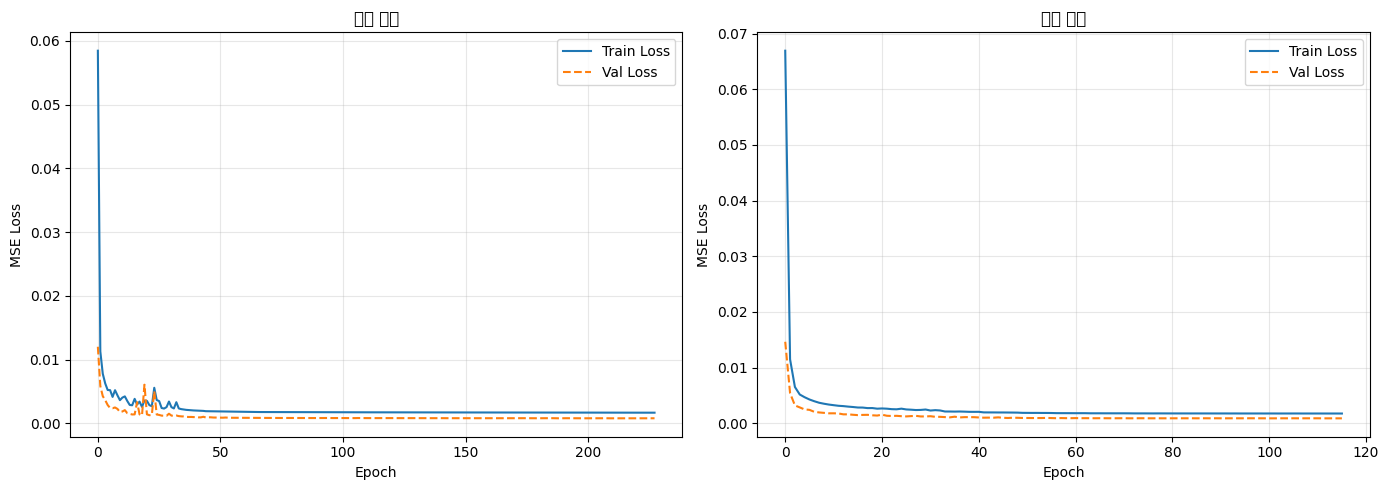

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, title in [
    (axes[0], history_boarding,  '승차 모델'),
    (axes[1], history_alighting, '하차 모델'),
]:
    ax.plot(hist.history['loss'],     label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss',  linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. 역별·날짜별 인터랙티브 시각화 (Plotly)

In [ ]:
def plot_station_day(station_name: str, line_name: str, date_str: str):
    """
    역명 + 호선 + 날짜 지정으로 실제vs예측 시각화
    예) plot_station_day('강남', '2호선', '2024-11-25')
    """
    key     = f"{station_name}_{line_name}"
    date_dt = pd.to_datetime(date_str)
    filtered = result[
        (result['역_키'] == key) &
        (result['날짜']  == date_dt)
    ].sort_values('시간').copy()

    if filtered.empty:
        print(f"데이터 없음: {key} / {date_str}")
        return

    # 시간 역정규화
    dummy = np.zeros((len(filtered), len(numeric_features)))
    dummy[:, numeric_features.index('시간')] = filtered['시간'].values
    filtered['실제시간'] = scaler.inverse_transform(dummy)[:, numeric_features.index('시간')].astype(int)

    x_axis = dict(title='시간', tickmode='linear', tick0=5, dtick=1,
                  range=[4, 24], fixedrange=True)

    for target, real_col, pred_col in [
        ('승차', '실제승차', '예측승차'),
        ('하차', '실제하차', '예측하차'),
    ]:
        fig = go.Figure([
            go.Scatter(x=filtered['실제시간'], y=filtered[real_col],
                       mode='lines+markers', name=f'실제 {target}'),
            go.Scatter(x=filtered['실제시간'], y=filtered[pred_col],
                       mode='lines+markers', name=f'예측 {target}', line=dict(dash='dash')),
        ])
        fig.update_layout(
            title=f"{station_name}({line_name}) {target}인원 ({date_str})",
            xaxis=x_axis,
            yaxis=dict(title=f'{target}인원 (명)', fixedrange=True),
            hovermode='x unified'
        )
        fig.show(config={'displayModeBar': False})

# 사용 예시
plot_station_day('강남', '2호선', '2024-11-25')
plot_station_day('여의도', '5호선', '2024-11-25')
plot_station_day('시청', '1호선', '2024-11-25')

## 14. 미래 예측 함수

> 단일 통합 모델이므로 잠실 분기 코드 없음 — 모든 역 동일 인터페이스

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

def predict_future(station_name: str, line_name: str, date_str: str, hour: int,
                   temp=None, rain=0.0, snow=0.0):
    key = f"{station_name}_{line_name}"

    if key not in le_station.classes_:
        print(f"[오류] '{key}' 는 학습 데이터에 없습니다.")
        print(f"  사용 가능한 역 목록 (일부): {list(le_station.classes_[:10])}")
        return None, None

    date_dt    = pd.to_datetime(date_str)
    month      = date_dt.month
    weekday    = date_dt.weekday()
    is_weekend = weekday >= 5
    is_holiday = 1 if (_cal.is_holiday(date_dt.date()) or is_weekend) else 0
    print(f"공휴일/주말: {'예' if is_holiday else '아니오'}")

    # 기온 자동 설정
    if temp is None:
        month_idx = numeric_features.index('월')
        _m = np.zeros((1, len(numeric_features)))
        _m[0, month_idx] = month
        month_scaled = scaler.transform(_m)[0][month_idx]
        temp_idx     = numeric_features.index('기온')
        mask         = np.abs(df['월'] - month_scaled) < 0.01
        temp_scaled_mean = df.loc[mask, '기온'].mean()
        _t = np.zeros((1, len(numeric_features)))
        _t[0, temp_idx] = temp_scaled_mean
        temp = scaler.inverse_transform(_t)[0][temp_idx]
        print(f"기온 자동: {temp:.1f}°C ({month}월 평균)")

    mask_key = df['역_키'] == key
    avg_b    = df.loc[mask_key, '역별_평균_승차'].mean()
    avg_a    = df.loc[mask_key, '역별_평균_하차'].mean()

    input_row = np.array([[
        0, 0,
        hour, weekday, month,
        is_holiday, temp, rain, snow,
        weekday * 24 + hour,
        0, 0
    ]])
    scaled_row = scaler.transform(input_row)
    scaled_row[0, numeric_features.index('역별_평균_승차')] = avg_b
    scaled_row[0, numeric_features.index('역별_평균_하차')] = avg_a

    station_enc = le_station.transform([key])[0]
    line_enc    = le_line.transform([line_name])[0]

    station_all = df[mask_key].copy().reset_index(drop=True)
    hour_idx    = numeric_features.index('시간')
    _h = np.zeros((1, len(numeric_features)))
    _h[0, hour_idx] = hour
    hour_scaled_val = scaler.transform(_h)[0][hour_idx]

    same_hour_idx = station_all[
        np.abs(station_all['시간'] - hour_scaled_val) < 0.01
    ].index.tolist()

    if not same_hour_idx:
        same_hour_idx = [np.abs(station_all['시간'] - hour_scaled_val).idxmin()]

    best_idx  = same_hour_idx[-1]
    start_idx = max(0, best_idx - SEQUENCE_LENGTH)
    seq_data  = station_all.iloc[start_idx:best_idx]

    if len(seq_data) < SEQUENCE_LENGTH:
        seq_data = station_all.iloc[best_idx: best_idx + SEQUENCE_LENGTH]

    seq = seq_data.tail(SEQUENCE_LENGTH)[numeric_features].values.copy()
    seq[-1] = scaled_row[0]

    X_pred         = seq.reshape(1, SEQUENCE_LENGTH, len(numeric_features)).astype(np.float32)
    X_station_pred = np.array([station_enc], dtype=np.int32)
    X_line_pred    = np.array([line_enc],    dtype=np.int32)

    pred_b = model_boarding.predict([X_pred, X_station_pred, X_line_pred], verbose=0)
    pred_a = model_alighting.predict([X_pred, X_station_pred, X_line_pred, pred_b], verbose=0).flatten()
    pred_b = pred_b.flatten()

    boarding_pred  = inverse_target(pred_b, scaler, 0, n_pad)[0]
    alighting_pred = inverse_target(pred_a, scaler, 1, n_pad)[0]

    weekday_names = ['월','화','수','목','금','토','일']
    print(f"\n{'='*45}")
    print(f"역명  : {station_name} ({line_name})")
    print(f"날짜  : {date_str}  {hour}시  ({weekday_names[weekday]}요일)")
    print(f"기온  : {temp:.1f}°C  강수량: {rain}mm  적설: {snow}cm")
    print(f"{'='*45}")
    print(f"예측 승차인원 : {boarding_pred:,.0f} 명")
    print(f"예측 하차인원 : {alighting_pred:,.0f} 명")
    print(f"{'='*45}")

    return boarding_pred, alighting_pred

# 사용 예시
predict_future('강남',               '2호선', '2026-12-25', 18)
predict_future('여의도',             '5호선', '2026-12-25', 18)
predict_future('잠실(송파구청)',     '2호선', '2026-12-25', 9)
predict_future('가산디지털단지',     '7호선', '2026-12-25', 8)
predict_future('월드컵경기장(성산)', '6호선', '2026-06-01', 15, rain=5.0)

공휴일/주말: 예
기온 자동: 1.3°C (12월 평균)

역명  : 강남 (2호선)
날짜  : 2026-12-25  18시  (금요일)
기온  : 1.3°C  강수량: 0.0mm  적설: 0.0cm
예측 승차인원 : 13,127 명
예측 하차인원 : 5,301 명
공휴일/주말: 예
기온 자동: 1.3°C (12월 평균)

역명  : 여의도 (5호선)
날짜  : 2026-12-25  18시  (금요일)
기온  : 1.3°C  강수량: 0.0mm  적설: 0.0cm
예측 승차인원 : 6,597 명
예측 하차인원 : 1,014 명
공휴일/주말: 예
기온 자동: 1.3°C (12월 평균)

역명  : 잠실(송파구청) (2호선)
날짜  : 2026-12-25  9시  (금요일)
기온  : 1.3°C  강수량: 0.0mm  적설: 0.0cm
예측 승차인원 : 3,945 명
예측 하차인원 : 7,955 명
공휴일/주말: 예
기온 자동: 1.3°C (12월 평균)

역명  : 가산디지털단지 (7호선)
날짜  : 2026-12-25  8시  (금요일)
기온  : 1.3°C  강수량: 0.0mm  적설: 0.0cm
예측 승차인원 : 750 명
예측 하차인원 : 8,446 명
공휴일/주말: 아니오
기온 자동: 24.6°C (6월 평균)

역명  : 월드컵경기장(성산) (6호선)
날짜  : 2026-06-01  15시  (월요일)
기온  : 24.6°C  강수량: 5.0mm  적설: 0.0cm
예측 승차인원 : 335 명
예측 하차인원 : 330 명


(np.float64(334.7037837089988), np.float64(329.9223189368242))

## 15. 역 임베딩 벡터 시각화 (선택)

학습된 임베딩에서 고수요 역끼리 가까운 클러스터를 형성하는지 PCA로 확인

임베딩 행렬 shape: (285, 16)
설명 분산 비율: [0.603813  0.1611177]


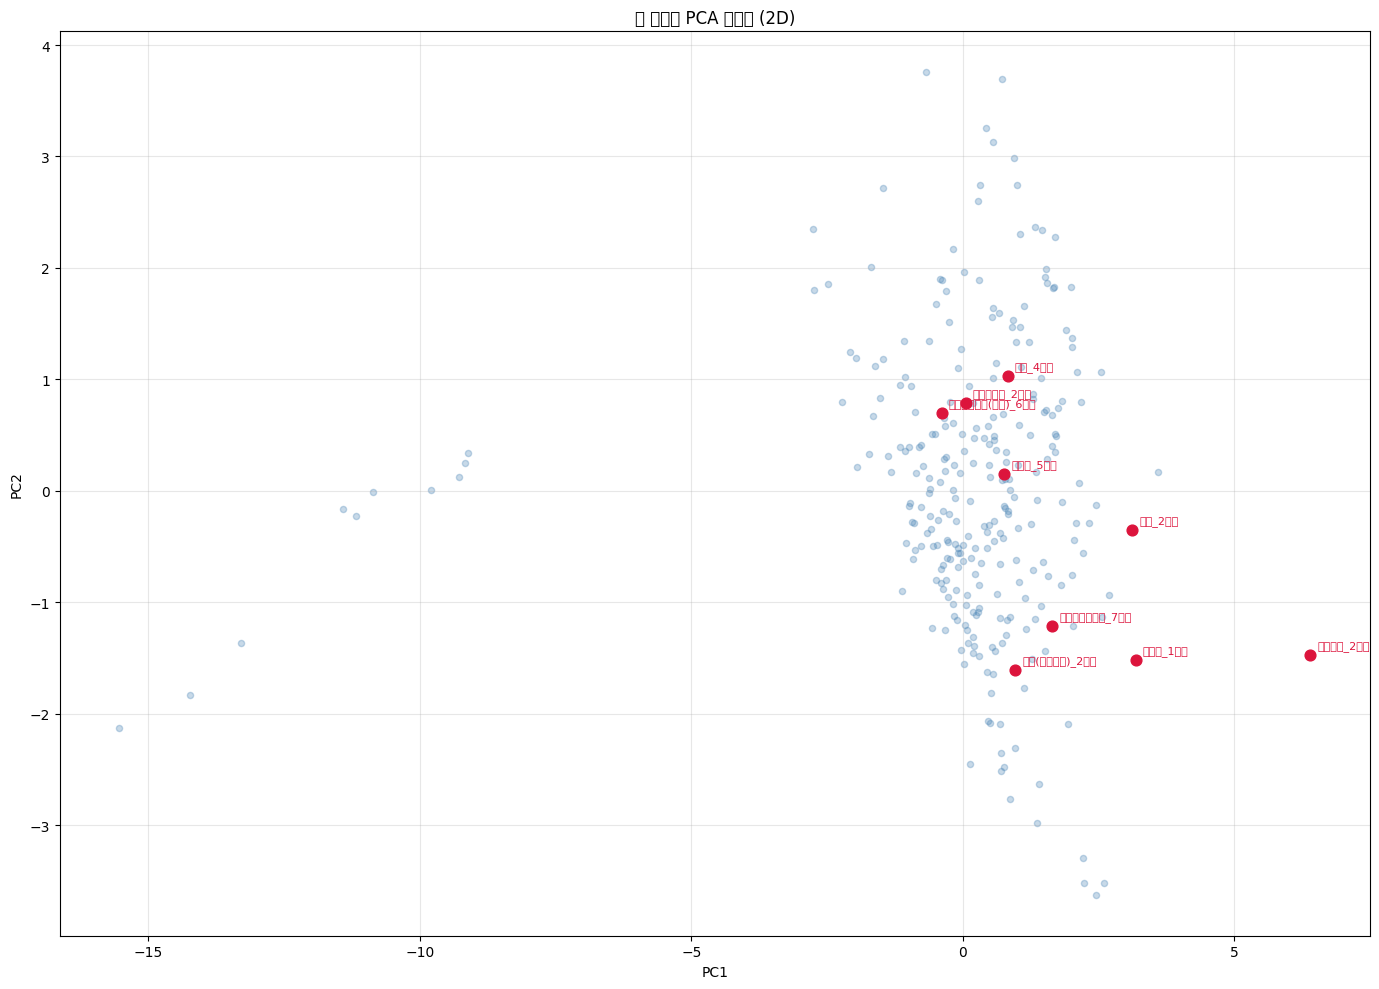

In [ ]:
from sklearn.decomposition import PCA

# 임베딩 가중치 추출
emb_weights = model_boarding.get_layer('station_embedding').get_weights()[0]
print(f"임베딩 행렬 shape: {emb_weights.shape}")   # (n_stations, 16)

# PCA 2차원 축소
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(emb_weights)
print(f"설명 분산 비율: {pca.explained_variance_ratio_}")

# 전체 산점도
plt.figure(figsize=(14, 10))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.3, s=20, c='steelblue')

# 주요 역 라벨링
highlight_keys = [
    '강남_2호선', '홍대입구_2호선', '잠실(송파구청)_2호선', '종합운동장_2호선',
    '여의도_5호선', '월드컵경기장(성산)_6호선', '가산디지털단지_7호선',
    '서울역_1호선', '명동_4호선'
]
for key in highlight_keys:
    if key in le_station.classes_:
        idx = le_station.transform([key])[0]
        plt.annotate(key, emb_2d[idx], fontsize=8, color='crimson',
                     xytext=(5, 5), textcoords='offset points')
        plt.scatter(*emb_2d[idx], s=60, c='crimson', zorder=5)

plt.title('역 임베딩 PCA 시각화 (2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 16. 모델 및 파일 저장

In [ ]:
# ── 모델 저장 ───────────────────────────────────────────────────────────────
model_boarding.save( SAVE_DIR + 'lstm_boarding_line1_8.keras')
model_alighting.save(SAVE_DIR + 'lstm_alighting_line1_8.keras')

# ── 스케일러 / 인코더 저장 ──────────────────────────────────────────────────
joblib.dump(scaler,      SAVE_DIR + 'scaler_line1_8.pkl')
joblib.dump(le_station,  SAVE_DIR + 'label_encoder_station_line1_8.pkl')
joblib.dump(le_line,     SAVE_DIR + 'label_encoder_line_line1_8.pkl')

# ── 피처 메타데이터 저장 ────────────────────────────────────────────────────
feature_info = {
    'time_steps'          : SEQUENCE_LENGTH,
    'features'            : numeric_features,
    'n_features'          : len(numeric_features),
    'n_stations'          : int(n_stations),
    'n_lines'             : int(n_lines),
    'embedding_dim_station': EMBEDDING_DIM_STATION,
    'embedding_dim_line'  : EMBEDDING_DIM_LINE,
    'station_key_format'  : '역명_호선  (예: 강남_2호선)',
    'multi_line_stations' : int((df.groupby('역명')['호선'].nunique() > 1).sum()),
}
with open(SAVE_DIR + 'feature_info_line1_8.json', 'w', encoding='utf-8') as f:
    json.dump(feature_info, f, ensure_ascii=False, indent=2)

# ── result 저장 ─────────────────────────────────────────────────────────────
result.to_csv(SAVE_DIR + 'result_line1_8.csv', index=False, encoding='utf-8-sig')

print("저장 완료:")
print(f"  {SAVE_DIR}")
print()
print(json.dumps(feature_info, ensure_ascii=False, indent=2))

저장 완료:
  /content/drive/MyDrive/Colab Notebooks/project_subway/line1_8/

{
  "time_steps": 12,
  "features": [
    "승차인원",
    "하차인원",
    "시간",
    "요일",
    "월",
    "공휴일여부",
    "기온",
    "강수량",
    "적설",
    "요일_시간",
    "역별_평균_승차",
    "역별_평균_하차"
  ],
  "n_features": 12,
  "n_stations": 285,
  "n_lines": 8,
  "embedding_dim_station": 16,
  "embedding_dim_line": 4,
  "station_key_format": "역명_호선  (예: 강남_2호선)",
  "multi_line_stations": 33
}


## 17. 최종 성능 요약

In [ ]:
print("=" * 60)
print("최종 모델 성능 요약 (Test set)")
print("=" * 60)
print_metrics("전체 승차", result['실제승차'], result['예측승차'])
print_metrics("전체 하차", result['실제하차'], result['예측하차'])

print("\n호선별 MAE:")
for line in sorted(result['호선'].unique()):
    sub = result[result['호선'] == line]
    mae = mean_absolute_error(sub['실제승차'], sub['예측승차'])
    print(f"  {line:6s}  승차 MAE: {mae:6.1f}명   (n={len(sub):,})")

print(f"\n학습 완료 모델: lstm_boarding_line1_8.keras / lstm_alighting_line1_8.keras")
print(f"역+호선 조합:   {n_stations}개  |  호선: {n_lines}개  |  총 데이터: {len(df):,}행")

최종 모델 성능 요약 (Test set)
[전체 승차     ]  MAE:   104.1명  |  RMSE:    246.3명  |  MAPE: 16.17%
[전체 하차     ]  MAE:   127.6명  |  RMSE:    360.9명  |  MAPE: 19.11%

호선별 MAE:
  1호선     승차 MAE:  148.4명   (n=29,220)
  2호선     승차 MAE:  185.1명   (n=146,100)
  3호선     승차 MAE:  100.2명   (n=97,284)
  4호선     승차 MAE:  130.9명   (n=75,972)
  5호선     승차 MAE:   74.4명   (n=163,632)
  6호선     승차 MAE:   58.3명   (n=108,574)
  7호선     승차 MAE:   82.3명   (n=122,802)
  8호선     승차 MAE:   61.6명   (n=53,206)

학습 완료 모델: lstm_boarding_line1_8.keras / lstm_alighting_line1_8.keras
역+호선 조합:   285개  |  호선: 8개  |  총 데이터: 3,986,800행


In [ ]:
# 승차
print(history_boarding.history['loss'][-5:])
print(history_boarding.history['val_loss'][-5:])

# 하차
print(history_alighting.history['loss'][-5:])
print(history_alighting.history['val_loss'][-5:])

[0.0016788550419732928, 0.0016796881100162864, 0.0016817508731037378, 0.0016811571549624205, 0.0016790699446573853]
[0.0007940912037156522, 0.0007968163699842989, 0.0008016024366952479, 0.0007984421099536121, 0.0008036415674723685]
[0.0017578034894540906, 0.00175685144495219, 0.0017567110480740666, 0.0017574891680851579, 0.0017529644537717104]
[0.0008907399023883045, 0.0008894834900274873, 0.0008911241893656552, 0.0008899029926396906, 0.0008897852385416627]
